# Mean Squared Displacement (MSD) Analysis for Coiled-Coil Proteins

This notebook calculates and analyzes the Mean Squared Displacement (MSD)
of coiled-coil proteins imaged through High-Speed Atomic Force Microscopy (HS-AFM).

# Methodology:

 - Computes MSD of <δR²(Δt)> and $\left\langle \delta \theta_{\mathrm{bend}}(\Delta t) \right\rangle$ for each monomer. 
  - Plot the $\left\langle \delta \theta_{\mathrm{bend}}(\Delta t) \right\rangle$ vs time interval ($(\Delta t)$)
 - Fits <δR²(Δt)> to extract mechanical parameters (Lp, tau)
 - Renormalizes <δR²(Δt)> for each configuration video 
 - Plots the rescaled <δR²(Δt)> vs rescaled time interval ($(\Delta t)$)

# Inputs:

 - HS-AFM image data in specified folder paths
 - Window size for MSD calculation (percentage of normalized arc length)


In [1]:
#Import required modules
import warnings
warnings.filterwarnings("ignore")

import numpy as np 
from statistics import geometric_mean

import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
import seaborn as sns

from scipy import stats
import os
import pandas as pd

from class_mech_gui import Filament_mech_gui

from constants import fit_l_p_header  # Headers for storing fitted MSD parameters into a dataframe
from constants import k_bT_nm,color_saha_configs_hex
from constants import x_bend_lt,y_bend_lt


from utils import find_folder_name,generate_lightness_and_transparency_variations
from utils import delta_R,fit_func_delta_L,renormalize_msd #functions required for fitting the MSD R


## Configuring the MSD analysis

In [2]:
#Window size for MSD calculation for a monomer. 
window_size_MSD = 0.50 # in percent of normalized arc length

# Folder path to the the traced filament coordinates of each frame stored as .csv  
folder_path_arr = ['S/1/']

# Generate configuration labels for each data folder
f_label_arr = [find_folder_name(os.path.dirname(
    f))+"_"+find_folder_name(f) for f in folder_path_arr]

## Calculating <δR²(Δt)>  and $\left\langle \delta \theta_{\mathrm{bend}}(\Delta t) \right\rangle$

In [3]:
# Dataframe to store MSD results
df_MSD_all = pd.DataFrame()

# Iterate through all data folder and compute MSD
for i in range(len(folder_path_arr)):
    # Initialize and create an object of Filament_mech_gui class
    S_config_obj = Filament_mech_gui(folder_path_arr[i], f_label_arr[i])

    # Calculate MSD using the R_TAN_BEND_MSD method
    df_msd, _, _ = S_config_obj.R_TAN_BEND_MSD(window_size_MSD)

    # Store all MSD results 
    df_MSD_all = pd.concat([df_MSD_all, df_msd])


## Plotting $\left\langle \delta \theta_{\mathrm{bend}}(\Delta t) \right\rangle$

S


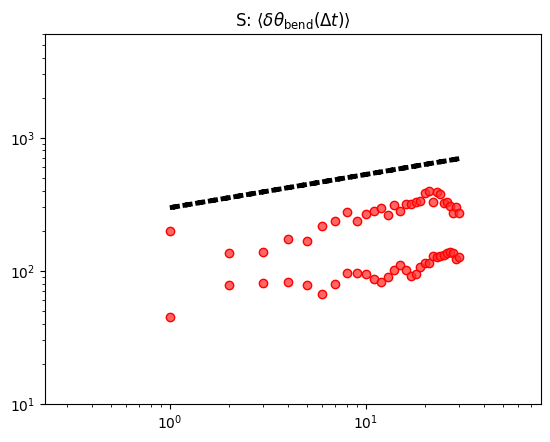

In [7]:
bend_ang_col_name = 'ang_wrt_mid_MSD'
for name, df_mask in  df_MSD_all.groupby(by='config_label'):

    color_hex = color_saha_configs_hex[name]
    n_files = len(df_mask['file_label'].unique())

    cmap_hex = generate_lightness_and_transparency_variations(
        color_hex, num_colors=n_files, min_lightness=0.3, max_lightness=0.9)

    plt.figure()
    plt.title(
        rf"{name}: $\langle \delta \theta_{{\mathrm{{bend}}}}(\Delta t) \rangle$")
    i_file = 0
    off_ref = 0.75 * max(df_mask[bend_ang_col_name])

    for _, df_mask1 in df_mask.groupby(['file_label']):
        print(name)
        t_data = df_mask1['deltaT_s'].to_numpy()
        MSD_R = df_mask1[bend_ang_col_name].to_numpy()

        plt.scatter(t_data, MSD_R,
                    c=cmap_hex[i_file], edgecolors=color_hex)

        plt.xscale('log');plt.yscale('log')


        plt.xlim(x_bend_lt);plt.ylim(y_bend_lt)
        i_file += 1
    plt.plot(t_data, off_ref*t_data**0.25, color='black',
                label='predicted FR method', linewidth=3.5, linestyle=':')

plt.show()



## Fitting the <δR²(Δt)> to extract L_p and τ

rc in loop :4.273750971271825,4.273750971271825
rc in loop :21.22892998531611,21.22892998531611


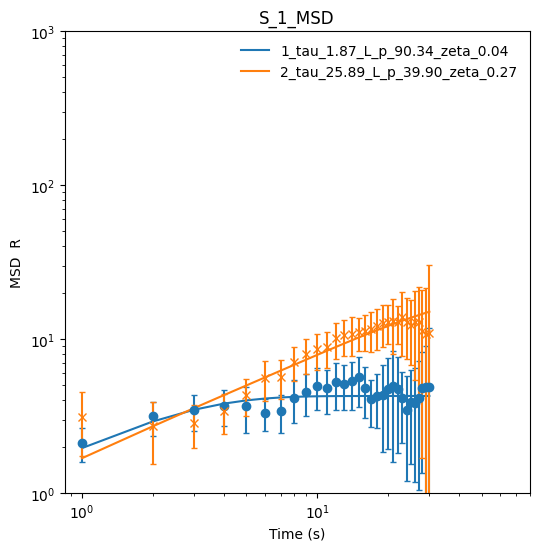

In [8]:
# Dataframe for storing fitted MSD parameters
df_fit_2 = pd.DataFrame(columns=fit_l_p_header)


for name, group in df_MSD_all.groupby(by='file_label'):
    df_temp = group
    bool_m = False # boolean for monomer fitting 
    df_fit_2 = pd.concat([df_fit_2, fit_func_delta_L(df_temp, monomer_bool=bool_m)], ignore_index=True)

# Renormalize MSD data using fitted parameters 
df_renorm_MSD = renormalize_msd(df_MSD_all,df_fit_2)

## Rescaled <δR²(Δt)> 

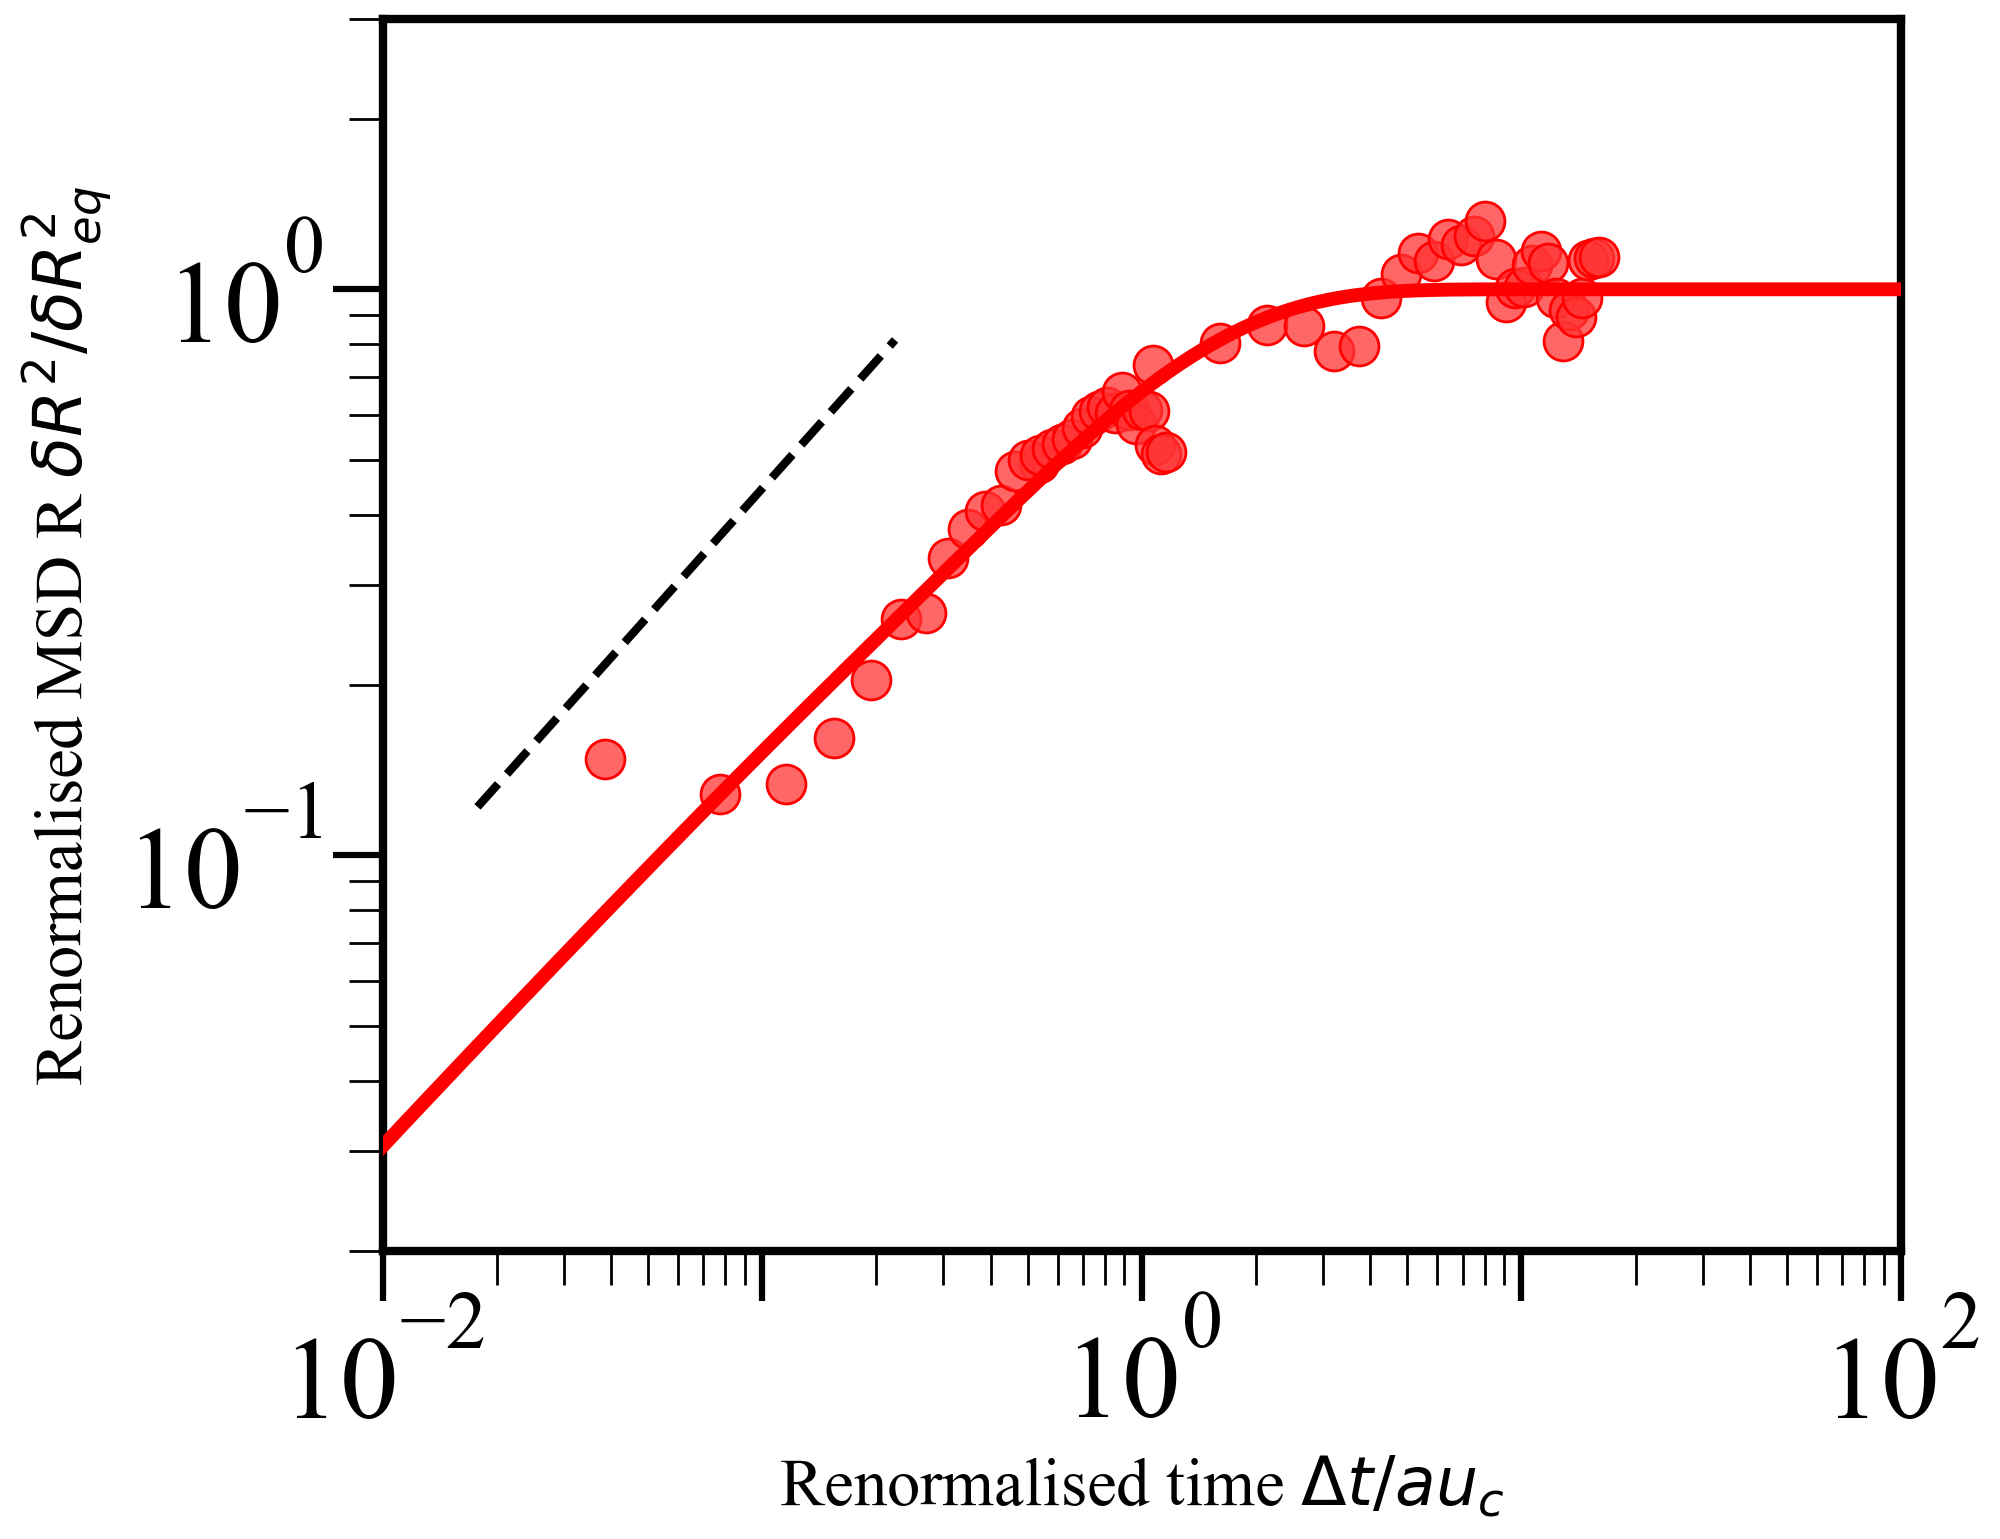

In [9]:
# Configure plotting parameters
plt.rcParams['figure.figsize'] = [9.796, 7.998]
plt.rcParams.update({'font.size': 22.016808, 'lines.markersize': 14, 'figure.dpi': 200, 'lines.color': 'black',
                     'xtick.major.size': 18, 'ytick.major.size': 18, 'xtick.minor.size': 12.15050424, 'ytick.minor.size': 12.15050424,
                     'font.family': 'Times New Roman', 'axes.linewidth': 3, "xtick.minor.visible": True, "ytick.minor.visible": True, 'xtick.major.width': 2.25,
                     'ytick.major.width': 2.25, 'xtick.minor.width': 1, 'ytick.minor.width': 1})

# Set axis limits for renormalized plot
x_renorm_limits = [0.01, 100]  # X-axis limits (renormalized time)
y_renorm_limit = [0.02, 3]  # Y-axis limits (renormalized MSD)
 
# Offset for reference line scaling line following a power law with a slope of 3/4 
off_ref_msd = 2.5
 
# Define tick positions and labels for logarithmic x-axis
x_ticks = [0.01, 0.1, 1, 10, 100]
x_tick_labels = ['$\\mathdefault{10^{-2}}$','', 
    '$\\mathdefault{10^{0}}$', '', '$\\mathdefault{10^{2}}$']
 
# Generate time array for theoretical prediction (logarithmic scale)
X_unnrom = np.logspace(-5.0, 8, num=1000)

# Generate resacled plots for each configuration
for name, df_config in df_renorm_MSD.groupby(['config_label']):
    plt.figure()
    
    # Compute minimum MSD for each file to determine color ordering    
    min_MSDs = df_config.groupby('file_label')['MSD'].min()

    # Sort labels by increasing MSD (lightest color first)
    sorted_labels = min_MSDs.sort_values().index

    # Calculate geometric mean of fitted parameters for current configuration
    L_avg_fit = geometric_mean(df_config['L_fitted'].to_numpy())  # Contour length
    L_p_avg_fit = geometric_mean(df_config['L_p_fitted'].to_numpy())  # Persistence length
    zeta_avg_fit = geometric_mean(df_config['zeta_fitted'].to_numpy())  # Friction coefficient
    tau_c = df_config['tau_c'].to_numpy()[0]  # Characteristic time
    
    # Step 1: Predict MSD using average fitted parameters
    MSD_pred_avg = delta_R(X_unnrom, zeta_avg_fit, L_p_avg_fit, L_avg_fit)

    # Step 2: Rescale time by characteristic time (dimensionless)
    tau = (zeta_avg_fit/(2*k_bT_nm*L_p_avg_fit)) * \
        pow((L_avg_fit/np.pi), 4)
    X_unnrom_rescaled = X_unnrom/tau

    # Step 3: Rescale MSD prediction for plotting
    MSD_pred_avg_rescaled = (90*L_p_avg_fit**2) * \
        MSD_pred_avg * (1/L_avg_fit)**4


    # Get configuration name and color
    name = name[0]
    color_hex = color_saha_configs_hex[name]
    
    # Count number of files for color variation
    n_files = len(df_config['file_label'].unique())
    file_label = (df_config['file_label'].to_numpy()[0][:-2])
    
    # Generate color palette with varying lightness/transparency
    # This creates visual distinction between different files
    cmap_hex = generate_lightness_and_transparency_variations(
        color_hex, num_colors=n_files, min_lightness=0.3, max_lightness=0.9)
    
    # Plot theoretical prediction
    plt.plot(X_unnrom_rescaled, MSD_pred_avg_rescaled,
                color=color_hex, label='predicted FR method', linewidth=5, zorder=100)
    
    # Plot experimental data for each file
    i_file = 0
    for t in reversed(sorted_labels):  # Plot in reverse order (darkest first)
        df_mask1 = df_renorm_MSD.groupby(['file_label']).get_group(t)
        t_data = df_mask1['dt_norm_indi_fit'].to_numpy()  # Renormalized time
        MSD_R = df_mask1['dR_norm_indi_fit'].to_numpy()  # Renormalized MSD
        
        # Scatter plot with color variation
        plt.scatter(t_data, MSD_R,
                    c=cmap_hex[i_file], edgecolors=color_hex, zorder=i_file)
        
        # Set logarithmic scales
        plt.xscale('log')
        plt.yscale('log')
        
        # Plot reference line (t^0.75 scaling for subdiffusive regime)
        temp_x = np.logspace(-1.75, -0.65, num=1000)
        plt.plot(temp_x, off_ref_msd*temp_x**0.75, color='black',
                    label='predicted FR method', linewidth=3, linestyle='--')
        
        # Set axis limits
        plt.xlim(x_renorm_limits)
        plt.ylim(y_renorm_limit)
        
        # Configure axis formatting
        ax = plt.gca()
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels)
        ax.set_ylabel("Renormalised MSD R $\delta R^2/\delta R^2_{eq}$", fontsize=24)
        ax.set_xlabel('Renormalised time $\Delta t/\tau_c$', fontsize=24)
        
        # Add logarithmic minor ticks
        ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=100))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=100))
        
        # Configure tick parameters
        ax.tick_params(axis='both', which='major', labelsize=42.016808)
        
        i_file += 1
plt.show()